In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import torch

In [76]:
datasets = []
for country in ["US", "GM", "FR", "UK", "IT"]:
    data = pd.read_csv(f"C:\\Users\\cgl_0\\OneDrive\\Thesis\\data\\input_datasets\\weekly_agg_8_features\\{country}data.csv")
    data = data[["mentions", "avg_tone", "avg_confidence"]]
    datasets.append(data)
datasets

[     mentions  avg_tone  avg_confidence
 0     1412844 -3.274277       44.147294
 1     1424307 -2.376029       42.823738
 2     1394723 -2.373024       42.974820
 3     1563252 -2.825826       42.802037
 4     1499463 -2.429398       43.012372
 ..        ...       ...             ...
 485    739778 -2.654566       41.749606
 486    730739 -2.595876       42.677194
 487    719763 -2.179390       41.242492
 488    663499 -2.442111       42.261480
 489    693631 -2.538520       42.279584
 
 [490 rows x 3 columns],
      mentions  avg_tone  avg_confidence
 0       71367 -5.444555       49.454510
 1       76105 -5.006341       45.795283
 2       72927 -3.026218       41.062021
 3       36535 -3.461167       48.111947
 4       42136 -3.445778       45.973277
 ..        ...       ...             ...
 485     14754 -1.287733       34.927477
 486     13571 -1.289884       42.226807
 487     27159 -1.474110       40.608270
 488     13972 -1.632338       40.912539
 489     14775 -2.433555      

In [77]:
def split_dfs_chronological(dfs, train_ratio=0.7, valid_ratio=0.15):
    """
    dfs: list of DataFrames, one per entity, same length
    returns train_dfs, valid_dfs, test_dfs
    """

    T = len(dfs[0])
    train_end = int(T * train_ratio)
    valid_end = int(T * (train_ratio + valid_ratio))

    train_dfs = [df.iloc[:train_end].copy() for df in dfs]
    valid_dfs = [df.iloc[train_end:valid_end].copy() for df in dfs]
    test_dfs  = [df.iloc[valid_end:].copy() for df in dfs]

    return train_dfs, valid_dfs, test_dfs

In [78]:
def dfs_to_cord_tensor(dfs, window_size=20, stride=1, normalize=True):
    """
    dfs: list of DataFrames, each shape [time_steps, features]
    returns: torch.Tensor with shape [batch, window_size, features, num_obj]
    """

    # [num_obj, time_steps, features]
    arr = np.stack([df[["mentions", "avg_tone", "avg_confidence"]].values
                    for df in dfs], axis=0)

    # [time_steps, features, num_obj]
    arr = np.transpose(arr, (1, 2, 0))

    delta = np.diff(arr, axis=0, prepend=arr[:1])
    arr = np.concatenate([arr, delta], axis=1)

    if normalize:
        # normalize per feature across time and objects
        mean = arr.mean(axis=(0, 2), keepdims=True)
        std = arr.std(axis=(0, 2), keepdims=True) + 1e-8
        arr = (arr - mean) / std

    windows = []
    for start in range(0, arr.shape[0] - window_size + 1, stride):
        end = start + window_size
        windows.append(arr[start:end])

    # [batch, window_size, features, num_obj]
    windows = np.stack(windows, axis=0).astype(np.float32)

    return torch.from_numpy(windows)

In [79]:
train_dfs

[     mentions  avg_tone  avg_confidence
 0     1412844 -3.274277       44.147294
 1     1424307 -2.376029       42.823738
 2     1394723 -2.373024       42.974820
 3     1563252 -2.825826       42.802037
 4     1499463 -2.429398       43.012372
 ..        ...       ...             ...
 338    654845 -3.024267       42.835114
 339    520788 -3.091275       41.832223
 340    580120 -2.822775       42.953820
 341    634144 -2.994723       41.814462
 342    542933 -2.729336       43.392684
 
 [343 rows x 3 columns],
      mentions  avg_tone  avg_confidence
 0       71367 -5.444555       49.454510
 1       76105 -5.006341       45.795283
 2       72927 -3.026218       41.062021
 3       36535 -3.461167       48.111947
 4       42136 -3.445778       45.973277
 ..        ...       ...             ...
 338     30737 -1.817301       40.076455
 339     12693 -1.693207       42.900024
 340     12863 -2.207108       44.701858
 341     14883 -2.465752       42.773634
 342     10878 -2.218230      

In [80]:
train_dfs, valid_dfs, test_dfs = split_dfs_chronological(datasets)

train_x = dfs_to_cord_tensor(train_dfs, window_size=10, stride=1)
valid_x = dfs_to_cord_tensor(valid_dfs, window_size=10, stride=1)
test_x  = dfs_to_cord_tensor(test_dfs, window_size=10, stride=1)

print(train_x.shape)
print(valid_x.shape)
print(test_x.shape)

torch.Size([334, 10, 6, 5])
torch.Size([64, 10, 6, 5])
torch.Size([65, 10, 6, 5])


In [81]:
x = dfs_to_cord_tensor(datasets, window_size=20, stride=1)

print(x.shape)

torch.Size([471, 20, 6, 5])


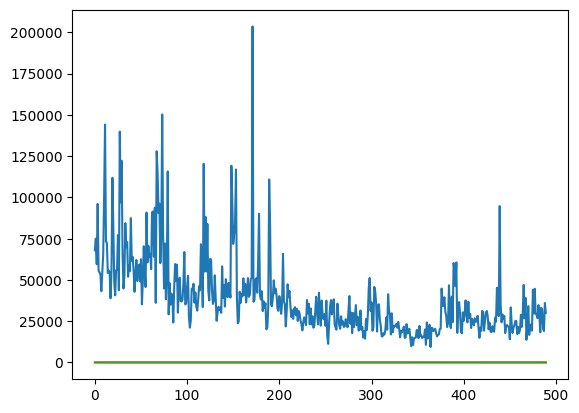

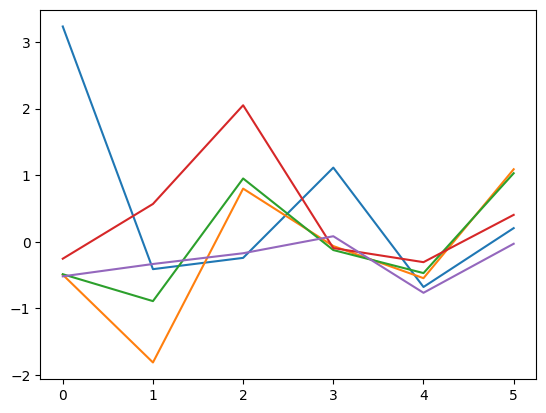

In [82]:
plt.plot(datasets[2])
plt.show()
plt.plot(x[0][7])

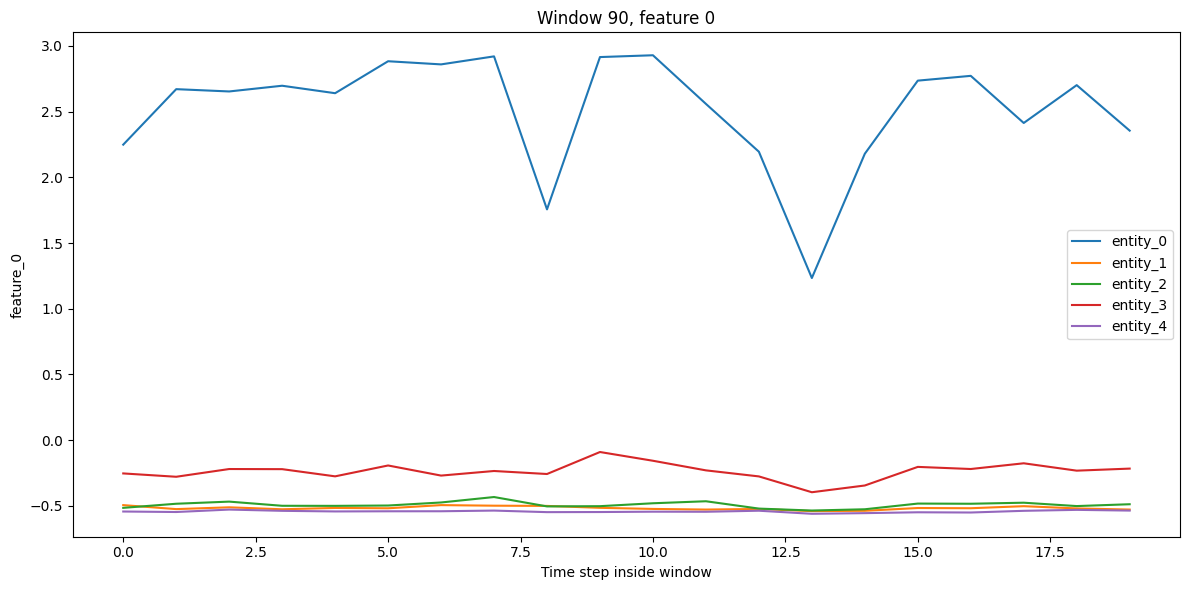

In [83]:
def plot_tensor_window(x, window_idx=0, feature_idx=1, entity_names=None):
    arr = x[window_idx].detach().cpu().numpy()
    # arr shape: [window_size, features, num_obj]

    num_obj = arr.shape[-1]

    if entity_names is None:
        entity_names = [f"entity_{i}" for i in range(num_obj)]

    plt.figure(figsize=(12, 6))

    for obj in range(num_obj):
        plt.plot(arr[:, feature_idx, obj], label=entity_names[obj])

    plt.xlabel("Time step inside window")
    plt.ylabel(f"feature_{feature_idx}")
    plt.title(f"Window {window_idx}, feature {feature_idx}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# feature indices: 0: mentions, 1: avg_tone, 2: avg_confidence
# entity indices: 0: US, 1: Germany, 2: France, 3: UK, 4: Italy
plot_tensor_window(x, window_idx=90, feature_idx=0)

In [84]:
train_x.shape[0]

334

## Save datasets

In [85]:
num_train, num_valid, num_test = [train_x.shape[0], valid_x.shape[0], test_x.shape[0]]

trainChangePoints = np.zeros(num_train, dtype=np.int64)
validChangePoints = np.zeros(num_valid, dtype=np.int64)
testChangePoints  = np.zeros(num_test, dtype=np.int64)

trainTargets = np.zeros(num_train, dtype=np.int64)
validTargets = np.zeros(num_valid, dtype=np.int64)
testTargets  = np.zeros(num_test, dtype=np.int64)

In [86]:
path = Path("C:/Users/cgl_0/CORD_CPD/data/cp_gdelt")

np.save(path / "trainFeatures.npy", train_x)
np.save(path / "validFeatures.npy", valid_x)
np.save(path / "testFeatures.npy", test_x)

np.save(path / "trainChangePoints.npy", trainChangePoints)
np.save(path / "validChangePoints.npy", validChangePoints)
np.save(path / "testChangePoints.npy", testChangePoints)

np.save(path / "trainTargets.npy", trainTargets)
np.save(path / "validTargets.npy", validTargets)
np.save(path / "testTargets.npy", testTargets)